## ****DATA UNDERSTANDING (PEMAHAMAN DATA)****

---

### ****PENGUMPULAN DAN IDENTIFIKASI DATA RELEVAN****

Tahap awal dilakukan dengan memuat data mentah yang sudah disediakan pihak kompetisi, untuk memetakan struktur, dimensi, dan kualitas data secara rinci sebelum eksplorasi lebih lanjut.

#### Pemuatan Data

Memuat file train.csv dan test.csv, lalu menampilkan dimensinya sebagai patokan awal ukuran data.

In [1]:
import pandas as pd
import numpy as np

In [2]:
train_path = "../Dataset/Raw/train.csv"
test_path = "../Dataset/Raw/test.csv"

df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

print(f"Dimensi Data Train : {df_train.shape[0]:,} baris, {df_train.shape[1]} kolom")

print("=================================================")

print(f"Dimensi Data Test : {df_test.shape[0]:,} baris, {df_test.shape[1]} kolom")

Dimensi Data Train : 1,054,200 baris, 21 kolom
Dimensi Data Test : 263,550 baris, 20 kolom


#### Struktur dan Tipe Data

Memeriksa tipe data, jumlah nilai unik, dan contoh nilai tiap kolom, untuk mengenali struktur data secara rinci sebelum analisis lebih lanjut.

In [3]:
datasets = {"TRAIN": df_train, "TEST": df_test}


def summarize_structure(df_dataset: pd.DataFrame) -> pd.DataFrame:
    """Ringkasan tipe data, jumlah nilai unik, dan contoh nilai tiap kolom."""
    return pd.DataFrame({
        "dtype": df_dataset.dtypes.astype(str),
        "n_unique": df_dataset.nunique(),
        "contoh_nilai": df_dataset.iloc[0],
    })


for dataset_name, df_dataset in datasets.items():
    memory_mb = df_dataset.memory_usage(deep=True).sum() / 1024**2
    print(f"{dataset_name}: {df_dataset.shape[0]:,} baris x {df_dataset.shape[1]} kolom | memori {memory_mb:,.1f} MB")
    display(summarize_structure(df_dataset))

TRAIN: 1,054,200 baris x 21 kolom | memori 325.4 MB


,dtype,n_unique,contoh_nilai
id,str,1054200,TRN_U8DHEL
timestamp,str,7028,2025-07-01 00:00:00
station_id,str,150,EV00001
station_name,str,148,ChargePoint - Los Angeles #1
network,str,8,ChargePoint
city,str,15,Los Angeles
state,str,13,CA
latitude,float64,150,34.012362
longitude,float64,150,-118.114786
location_type,str,8,Shopping Center


TEST: 263,550 baris x 20 kolom | memori 79.2 MB


,dtype,n_unique,contoh_nilai
id,str,263550,TST_0U33RJ
timestamp,str,1757,2025-11-24 10:00:00
station_id,str,150,EV00049
station_name,str,148,Volta - Boston #9
network,str,8,Volta
city,str,15,Boston
state,str,13,MA
latitude,float64,150,42.473202
longitude,float64,150,-71.132618
location_type,str,8,Workplace


#### Nilai Kosong

Memeriksa jumlah dan persentase nilai kosong tiap kolom, sebagai dasar keputusan imputasi pada tahap Data Preparation.

In [4]:
def summarize_missing(df_dataset: pd.DataFrame) -> pd.DataFrame:
    """Jumlah dan persentase nilai kosong per kolom (hanya kolom yang memiliki nilai kosong)."""
    n_missing = df_dataset.isna().sum()
    summary = pd.DataFrame({
        "n_missing": n_missing,
        "persen_missing": (n_missing / len(df_dataset) * 100).round(2),
    })
    return summary[summary["n_missing"] > 0].sort_values("n_missing", ascending=False)


for dataset_name, df_dataset in datasets.items():
    print(f"Nilai kosong {dataset_name}:")
    display(summarize_missing(df_dataset))

Nilai kosong TRAIN:


,n_missing,persen_missing
temperature_f,44160,4.19
precipitation_mm,24032,2.28


Nilai kosong TEST:


,n_missing,persen_missing
temperature_f,10928,4.15
precipitation_mm,6178,2.34


#### Data Duplikat

Memeriksa duplikasi baris, id, dan kombinasi (timestamp, station_id), untuk memastikan tidak ada pencatatan ganda yang bisa mendistorsi analisis.

In [5]:
# Mengecek nilai duplikat

for dataset_name, df_dataset in datasets.items():
    n_duplicate_rows = df_dataset.duplicated().sum()
    n_duplicate_ids = df_dataset["id"].duplicated().sum()
    n_duplicate_keys = df_dataset.duplicated(subset=["timestamp", "station_id"]).sum()
    print(
        f"{dataset_name} | baris duplikat: {n_duplicate_rows:,} "
        f"| id duplikat: {n_duplicate_ids:,} "
        f"| duplikat (timestamp, station_id): {n_duplicate_keys:,}"
    )

TRAIN | baris duplikat: 0 | id duplikat: 0 | duplikat (timestamp, station_id): 0
TEST | baris duplikat: 0 | id duplikat: 0 | duplikat (timestamp, station_id): 0


#### ****Temuan Struktur dan Kualitas Data Awal****

- Kedua dataset memuat 150 stasiun (station_id), dengan satu pasang koordinat per stasiun.
- Train memiliki 7.028 timestamp dan test 1.757 timestamp. Karena 150 x 7.028 = 1.054.200 dan 150 x 1.757 = 263.550, serta tidak ada duplikat pasangan (timestamp, station_id), setiap stasiun tercatat pada setiap timestamp (panel seimbang). Kontinuitas jarak 30 menit antartimestamp masih perlu diperiksa.
- station_name hanya memiliki 148 nilai unik untuk 150 station_id, sehingga ada nama yang dipakai lebih dari satu stasiun.
- timestamp masih bertipe string dan perlu dikonversi ke datetime.
- amenities_nearby memiliki 123 kombinasi berupa teks multi-nilai yang dipisahkan koma.
- Nilai kosong hanya pada temperature_f (train 4,19%, test 4,15%) dan precipitation_mm (train 2,28%, test 2,34%) dengan proporsi yang serupa antara train dan test. Kolom lain lengkap.
- Tidak ada duplikat baris, id, maupun pasangan (timestamp, station_id).
- weather_condition memiliki 7 kategori di train dan 6 di test.

---

### ****STATISTIK DESKRIPTIF DAN VALIDITAS DATA****

#### Statistik Deskriptif Numerik

Menghitung ringkasan statistik (rata-rata, sebaran, persentil, minimum, maksimum) untuk fitur numerik dan target. Tujuannya mengenali skala dan sebaran nilai, mendeteksi indikasi outlier, serta membandingkan distribusi train dan test.

In [6]:
feature_numeric_cols = ["power_output_kw", "ports_total", "temperature_f", "precipitation_mm", "gas_price_per_gallon"]
describe_percentiles = [0.01, 0.25, 0.5, 0.75, 0.99]

for dataset_name, df_dataset in datasets.items():
    numeric_cols = feature_numeric_cols + (["utilization_rate"] if "utilization_rate" in df_dataset else [])
    print(f"Statistik deskriptif numerik {dataset_name}:")
    display(df_dataset[numeric_cols].describe(percentiles=describe_percentiles).T.round(3))

Statistik deskriptif numerik TRAIN:


,count,mean,std,min,1%,25%,50%,75%,99%,max
power_output_kw,1054200.0,134.588,128.510,7.20,7.20,19.200,100.000,250.000,350.00,350.00
ports_total,1054200.0,7.307,4.484,2.00,2.00,4.000,6.000,8.000,24.00,24.00
temperature_f,1010040.0,77.152,18.188,20.10,27.00,68.000,79.800,90.100,106.40,110.00
precipitation_mm,1030168.0,0.531,2.247,0.00,0.00,0.000,0.000,0.000,11.80,62.80
gas_price_per_gallon,1054200.0,3.891,0.587,3.28,3.28,3.440,3.590,4.310,5.32,5.50
utilization_rate,1054200.0,0.407,0.295,0.02,0.02,0.121,0.392,0.634,0.98,0.98


Statistik deskriptif numerik TEST:


,count,mean,std,min,1%,25%,50%,75%,99%,max
power_output_kw,263550.0,134.588,128.510,7.20,7.20,19.20,100.00,250.0,350.00,350.0
ports_total,263550.0,7.307,4.484,2.00,2.00,4.00,6.00,8.0,24.00,24.0
temperature_f,252622.0,49.772,16.329,20.10,22.80,34.80,47.70,64.8,77.10,79.9
precipitation_mm,257372.0,0.786,2.700,0.00,0.00,0.00,0.00,0.0,13.90,51.9
gas_price_per_gallon,263550.0,4.149,0.614,3.54,3.55,3.68,3.83,4.6,5.47,5.5


#### Validitas Rentang Nilai

Menghitung jumlah nilai yang melanggar batas logis (misalnya curah hujan negatif, kapasitas daya nol, atau target di luar 0 sampai 1). Tujuannya memastikan tidak ada nilai mustahil yang perlu dibersihkan pada tahap Data Preparation.

In [7]:
def count_invalid_values(df_dataset: pd.DataFrame) -> pd.Series:
    """Hitung nilai di luar rentang logis; aturan target hanya berlaku bila kolomnya ada."""
    checks = {
        "precipitation_mm < 0": df_dataset["precipitation_mm"] < 0,
        "power_output_kw <= 0": df_dataset["power_output_kw"] <= 0,
        "ports_total <= 0": df_dataset["ports_total"] <= 0,
        "gas_price_per_gallon <= 0": df_dataset["gas_price_per_gallon"] <= 0,
    }
    if "utilization_rate" in df_dataset:
        checks.update({
            "utilization_rate < 0": df_dataset["utilization_rate"] < 0,
            "utilization_rate > 1": df_dataset["utilization_rate"] > 1,
            "utilization_rate == 0": df_dataset["utilization_rate"] == 0,
            "utilization_rate == 1": df_dataset["utilization_rate"] == 1,
        })
    return pd.Series({rule: int(mask.sum()) for rule, mask in checks.items()})


display(pd.DataFrame({dataset_name: count_invalid_values(df_dataset)
                      for dataset_name, df_dataset in datasets.items()}))

,TRAIN,TEST
gas_price_per_gallon <= 0,0,0.0
ports_total <= 0,0,0.0
power_output_kw <= 0,0,0.0
precipitation_mm < 0,0,0.0
utilization_rate < 0,0,NaN
utilization_rate == 0,0,NaN
utilization_rate == 1,0,NaN
utilization_rate > 1,0,NaN


#### Profil Fitur Kategorik (Train vs Test)

Membandingkan proporsi setiap kategori antara train dan test. Tujuannya menemukan kategori yang hanya muncul di salah satu dataset dan pergeseran distribusi yang dapat mengganggu generalisasi model.

In [8]:
categorical_cols = ["network", "city", "state", "location_type",
                    "charger_type", "pricing_type", "weather_condition", "local_event"]

for col in categorical_cols:
    category_share = pd.concat(
        {dataset_name: df_dataset[col].value_counts(normalize=True).mul(100).round(2)
         for dataset_name, df_dataset in datasets.items()},
        axis=1,
    ).fillna(0)
    print(f"{col}: {len(category_share)} kategori")
    display(category_share)

network: 8 kategori


,TRAIN,TEST
network,,
Electrify America,16.00,16.00
Volta,14.67,14.67
Tesla Supercharger,14.00,14.00
Shell Recharge,14.00,14.00
Blink,14.00,14.00
ChargePoint,11.33,11.33
EVCS,10.67,10.67
EVgo,5.33,5.33


city: 15 kategori


,TRAIN,TEST
city,,
Phoenix,12.00,12.00
Atlanta,7.33,7.33
Seattle,6.67,6.67
Miami,6.67,6.67
Minneapolis,6.67,6.67
Chicago,6.67,6.67
San Francisco,6.67,6.67
Denver,6.67,6.67
Los Angeles,6.00,6.00


state: 13 kategori


...

,TRAIN,TEST
pricing_type,,
per_kwh,80.00,80.00
free,14.67,14.67
per_minute,5.33,5.33


weather_condition: 7 kategori


,TRAIN,TEST
weather_condition,,
clear,36.53,35.05
cloudy,18.30,17.56
partly_cloudy,18.26,17.67
extreme_heat,14.15,0.00
light_rain,9.07,13.26
freezing,2.27,14.30
heavy_rain,1.43,2.16


local_event: 5 kategori


,TRAIN,TEST
local_event,,
none,97.58,97.64
festival,0.61,0.59
conference,0.61,0.59
concert,0.60,0.59
sports_game,0.60,0.58


#### ****Temuan Statistik Deskriptif, Validitas Nilai, dan Profil Kategorik****

**Fitur numerik**
- power_output_kw dan ports_total identik di train dan test (rata-rata 134,588 dan 7,307) karena kedua dataset memuat 150 stasiun yang sama. Tidak ada stasiun baru pada test.
- utilization_rate: rata-rata 0,407 dan standar deviasi 0,295, dengan rentang 0,02 sampai 0,98. Persentil 1% dan 99% sama dengan minimum dan maksimum, **artinya target terpotong pada 0,02 dan 0,98** dengan banyak observasi di kedua batas.
- temperature_f: train rata-rata 77,15 (20,1 sampai 110,0), test rata-rata 49,77 (20,1 sampai 79,9). Test jauh lebih dingin, dan suhu di test tidak pernah melebihi 79,9 padahal median train adalah 79,8.
- precipitation_mm: condong ke kanan, 75% nilai adalah 0, maksimum 62,8 (train) dan 51,9 (test). Nilai ekstrem perlu dibedakan antara hujan lebat nyata dan noise sensor.
- gas_price_per_gallon: train 3,28 sampai 5,50 (rata-rata 3,891), test 3,54 sampai 5,50 (rata-rata 4,149). Harga cenderung lebih tinggi pada periode test, sehingga perlu diperiksa apakah berperan sebagai penanda waktu.

**Validitas nilai**
- Tidak ada nilai di luar rentang logis. Tidak ada nilai negatif atau nol pada kolom fisik, dan target tidak mengandung 0, 1, atau lebih dari 1.

**Fitur kategorik**
- network, city, state, location_type, charger_type, dan pricing_type memiliki proporsi identik di train dan test, konsekuensi dari 150 stasiun yang sama.
- weather_condition bergeser: extreme_heat 14,15% di train dan tidak ada di test, freezing dari 2,27% (train) menjadi 14,30% (test), light_rain dari 9,07% menjadi 13,26%. Model harus memprediksi kondisi dingin yang contohnya sedikit di train.
- local_event: 97,6% berisi none, sedangkan tiap jenis acara sekitar 0,6% dengan proporsi stabil antara train dan test.

---

### ****KONTINUITAS WAKTU DAN INTEGRITAS ENTITAS****

#### Kontinuitas Waktu

Mengonversi timestamp ke tipe datetime, lalu memeriksa rentang periode, jumlah timestamp dibanding yang seharusnya (interval 30 menit), hari yang tidak lengkap, dan jeda antara akhir train dengan awal test. Tujuannya menemukan celah waktu (termasuk 31 Desember 2025) sebelum melakukan agregasi atau fitur berbasis waktu.

In [9]:
timestamp_col = "timestamp"
expected_interval = pd.Timedelta(minutes=30)
expected_daily_records = 48

for df_dataset in datasets.values():
    df_dataset[timestamp_col] = pd.to_datetime(df_dataset[timestamp_col])


def get_unique_timestamps(df_dataset: pd.DataFrame) -> pd.Series:
    """Ambil timestamp unik yang sudah terurut."""
    return df_dataset[timestamp_col].drop_duplicates().sort_values().reset_index(drop=True)


def summarize_time_continuity(df_dataset: pd.DataFrame) -> pd.Series:
    """Ringkas rentang periode dan celah antartimestamp berurutan."""
    unique_timestamps = get_unique_timestamps(df_dataset)
    start, end = unique_timestamps.iloc[0], unique_timestamps.iloc[-1]
    return pd.Series({
        "awal": start,
        "akhir": end,
        "n_timestamp": len(unique_timestamps),
        "n_timestamp_seharusnya": int((end - start) / expected_interval) + 1,
        "n_celah": int((unique_timestamps.diff().dropna() != expected_interval).sum()),
    })


def find_incomplete_days(df_dataset: pd.DataFrame) -> pd.Series:
    """Hari dengan jumlah timestamp berbeda dari 48 (data 30 menit)."""
    daily_counts = get_unique_timestamps(df_dataset).dt.normalize().value_counts().sort_index()
    return daily_counts[daily_counts != expected_daily_records]


display(pd.DataFrame({name: summarize_time_continuity(df) for name, df in datasets.items()}))

for dataset_name, df_dataset in datasets.items():
    n_station_per_timestamp = df_dataset.groupby(timestamp_col)["station_id"].nunique().value_counts()
    print(f"{dataset_name} | sebaran jumlah stasiun per timestamp: {n_station_per_timestamp.to_dict()}")
    print(f"{dataset_name} | hari tidak lengkap (jumlah timestamp per hari):")
    display(find_incomplete_days(df_dataset).to_frame("n_timestamp"))

print(f"Jeda akhir train ke awal test: {df_test[timestamp_col].min() - df_train[timestamp_col].max()}")

,TRAIN,TEST
awal,2025-07-01 00:00:00,2025-11-24 10:00:00
akhir,2025-11-24 09:30:00,2025-12-31 00:00:00
n_timestamp,7028,1757
n_timestamp_seharusnya,7028,1757
n_celah,0,0


TRAIN | sebaran jumlah stasiun per timestamp: {150: 7028}
TRAIN | hari tidak lengkap (jumlah timestamp per hari):


,n_timestamp
timestamp,
2025-11-24,20


TEST | sebaran jumlah stasiun per timestamp: {150: 1757}
TEST | hari tidak lengkap (jumlah timestamp per hari):


,n_timestamp
timestamp,
2025-11-24,28
2025-12-31,1


Jeda akhir train ke awal test: 0 days 00:30:00


#### Integritas Entitas Stasiun

Membentuk profil satu baris per stasiun, lalu memeriksa apakah atribut statis konsisten per station_id, stasiun mana yang berbagi nama, dan apakah himpunan stasiun di train dan test sama. Tujuannya memastikan station_id aman dipakai sebagai kunci entitas.

In [10]:
static_station_cols = ["station_name", "network", "city", "state", "latitude", "longitude",
                       "location_type", "charger_type", "power_output_kw", "ports_total",
                       "amenities_nearby", "pricing_type"]

station_profile = (
    pd.concat([df_dataset[["station_id"] + static_station_cols] for df_dataset in datasets.values()])
    .drop_duplicates()
    .reset_index(drop=True)
)

n_inconsistent_by_col = station_profile.groupby("station_id")[static_station_cols].nunique().gt(1).sum()
print(f"Baris profil unik: {len(station_profile)} | station_id unik: {station_profile['station_id'].nunique()}")
print(f"Kolom dengan nilai berbeda untuk station_id yang sama: {n_inconsistent_by_col[n_inconsistent_by_col > 0].to_dict()}")
print(f"Himpunan stasiun train sama dengan test: {set(df_train['station_id']) == set(df_test['station_id'])}")

station_per_name = station_profile.groupby("station_name")["station_id"].nunique()
duplicated_names = station_per_name[station_per_name > 1].index

display(
    station_profile[station_profile["station_name"].isin(duplicated_names)]
    .sort_values(["station_name", "station_id"])
    [["station_name", "station_id", "city", "latitude", "longitude",
      "location_type", "charger_type", "power_output_kw", "ports_total"]]
)

Baris profil unik: 150 | station_id unik: 150
Kolom dengan nilai berbeda untuk station_id yang sama: {}
Himpunan stasiun train sama dengan test: True


,station_name,station_id,city,latitude,longitude,location_type,charger_type,power_output_kw,ports_total
90,Electrify America - Phoenix #11,EV00071,Phoenix,33.510745,-112.112153,Hotel/Hospitality,Hyper-Fast,350.0,2
2,Electrify America - Phoenix #11,EV00131,Phoenix,33.509449,-112.059171,Airport,DC Fast Charge,350.0,6
73,Volta - San Diego #10,EV00010,San Diego,32.859690,-117.067481,Hotel/Hospitality,Level 2,7.2,4
91,Volta - San Diego #10,EV00070,San Diego,32.833212,-117.087769,Suburban,Level 2,7.2,4


#### Konsistensi Spesifikasi Charger

Menyilangkan charger_type dengan power_output_kw dan network pada level stasiun. Tujuannya menemukan kombinasi yang janggal (misalnya jenis charger tidak sesuai dayanya) yang dapat menjadi noise atau justru fitur informatif.

In [11]:
print("charger_type x power_output_kw (jumlah stasiun):")
display(pd.crosstab(station_profile["charger_type"], station_profile["power_output_kw"]))

print("network x charger_type (jumlah stasiun):")
display(pd.crosstab(station_profile["network"], station_profile["charger_type"]))

charger_type x power_output_kw (jumlah stasiun):


power_output_kw,7.2,19.2,50.0,62.5,100.0,125.0,150.0,250.0,350.0
charger_type,,,,,,,,,
DC Fast Charge,7,3,15,4,5,1,15,0,19
Hyper-Fast,0,0,0,0,0,0,7,0,4
Level 2,28,8,4,2,4,3,0,0,0
Tesla DC Fast,0,0,0,0,0,0,5,7,9


network x charger_type (jumlah stasiun):


charger_type,DC Fast Charge,Hyper-Fast,Level 2,Tesla DC Fast
network,,,,
Blink,10,0,11,0
ChargePoint,8,0,9,0
EVCS,9,0,7,0
EVgo,8,0,0,0
Electrify America,13,11,0,0
Shell Recharge,21,0,0,0
Tesla Supercharger,0,0,0,21
Volta,0,0,22,0


#### ****Temuan Kontinuitas Waktu, Integritas Stasiun, dan Konsistensi Spesifikasi****

**Kontinuitas waktu**
- Train mencakup 1 Juli 2025 00:00 sampai 24 November 2025 09:30 (7.028 timestamp), dan test mencakup 24 November 2025 10:00 sampai 31 Desember 2025 00:00 (1.757 timestamp). Jumlah timestamp sama dengan jumlah seharusnya pada interval 30 menit, tanpa celah di dalam kedua dataset.
- Setiap timestamp memuat tepat 150 stasiun, sehingga panel seimbang dan tidak ada observasi yang hilang.
- Tanggal 24 November terbagi antara train (20 timestamp) dan test (28 timestamp), totalnya 48, sehingga lengkap bila digabung. Test dimulai tepat setelah train berakhir.
- Tanggal 31 Desember 2025 hanya memiliki satu timestamp (00:00). Kesenjangan ini berupa data yang berhenti di awal hari, bukan lubang di tengah rangkaian. Agregasi harian atau mingguan yang memasukkan 31 Desember hanya bertumpu pada satu titik waktu, sehingga hari tersebut perlu dikecualikan dari agregasi.

**Integritas stasiun**
- Terdapat 150 profil unik untuk 150 station_id, tidak ada atribut yang berubah untuk station_id yang sama, dan himpunan stasiun di train sama persis dengan test. station_id aman sebagai kunci entitas dan tidak ada stasiun baru pada test.
- Dua nama dipakai oleh dua stasiun berbeda: Electrify America - Phoenix #11 (EV00071 dan EV00131) dan Volta - San Diego #10 (EV00010 dan EV00070). Pasangan tersebut berbeda pada koordinat (berjarak kurang lebih 5 km dan 3,5 km) dan location_type, sedangkan pasangan Phoenix juga berbeda pada charger_type dan ports_total. Keduanya entitas fisik terpisah, sehingga merge dan groupby wajib memakai station_id.

**Konsistensi spesifikasi**
- charger_type tidak selaras dengan power_output_kw: 10 stasiun DC Fast Charge berdaya 7,2 atau 19,2 kW, dan 13 stasiun Level 2 berdaya 50 sampai 125 kW (total 23 dari 150 stasiun), yang tidak lazim untuk jenisnya. Kedua kolom dipertahankan sebagai fitur terpisah tanpa dikoreksi manual.
- network menentukan charger_type dengan kuat: Tesla Supercharger hanya Tesla DC Fast, Volta hanya Level 2, EVgo dan Shell Recharge hanya DC Fast Charge, dan Electrify America hanya DC Fast Charge dan Hyper-Fast. Hanya Blink, ChargePoint, dan EVCS yang memiliki campuran DC Fast Charge dan Level 2. Kedua kolom saling berkaitan (redundan).

---

### ****EKSPLORASI TARGET (UTILIZATION_RATE)****

#### Distribusi Target

Memeriksa bentuk distribusi utilization_rate, jumlah observasi pada batas bawah dan atas, serta sebaran rata-rata target antarstasiun. Tujuannya mengetahui apakah target terpotong, condong, atau bimodal, karena hal ini memengaruhi pilihan model dan batas prediksi.

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

,n_baris,persen
target == 0.02,34662,3.29
target == 0.98,49603,4.71


Skewness: 0.347 | Kurtosis: -1.077


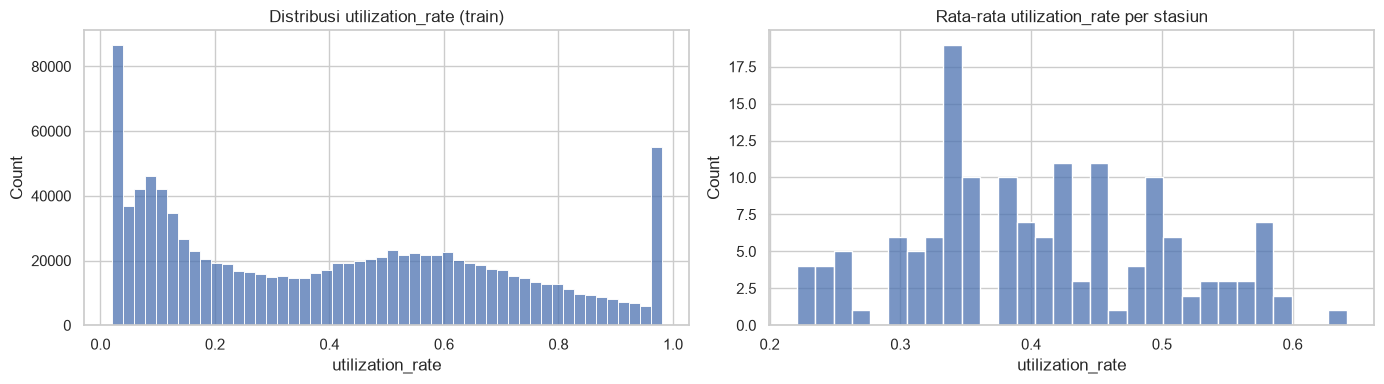

In [13]:
sns.set_theme(style="whitegrid")

target_col = "utilization_rate"
target_series = df_train[target_col]
target_min, target_max = target_series.min(), target_series.max()

boundary_summary = pd.DataFrame(
    {"n_baris": [(target_series == target_min).sum(), (target_series == target_max).sum()]},
    index=[f"target == {target_min}", f"target == {target_max}"],
)
boundary_summary["persen"] = (boundary_summary["n_baris"] / len(target_series) * 100).round(2)
display(boundary_summary)
print(f"Skewness: {target_series.skew():.3f} | Kurtosis: {target_series.kurt():.3f}")

station_mean_target = df_train.groupby("station_id")[target_col].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(target_series, bins=50, ax=axes[0])
axes[0].set_title("Distribusi utilization_rate (train)")
sns.histplot(station_mean_target, bins=30, ax=axes[1])
axes[1].set_title("Rata-rata utilization_rate per stasiun")
plt.tight_layout()
plt.show()

#### Pola Temporal Target

Menurunkan fitur waktu (jam, hari dalam minggu, bulan) dari timestamp, lalu melihat rata-rata target per jam (hari kerja vs akhir pekan), heatmap hari x jam, tren harian, dan rata-rata bulanan. Tren harian hanya memakai hari dengan 48 timestamp lengkap agar tidak terdistorsi hari parsial. Tujuannya mengidentifikasi jam sibuk dan tren yang akan menentukan rekayasa fitur temporal.

Jam dengan rata-rata tertinggi per tipe hari:
day_type
Akhir pekan    18
Hari kerja     12
dtype: int32
Hari tidak lengkap yang dikecualikan dari tren harian: 1


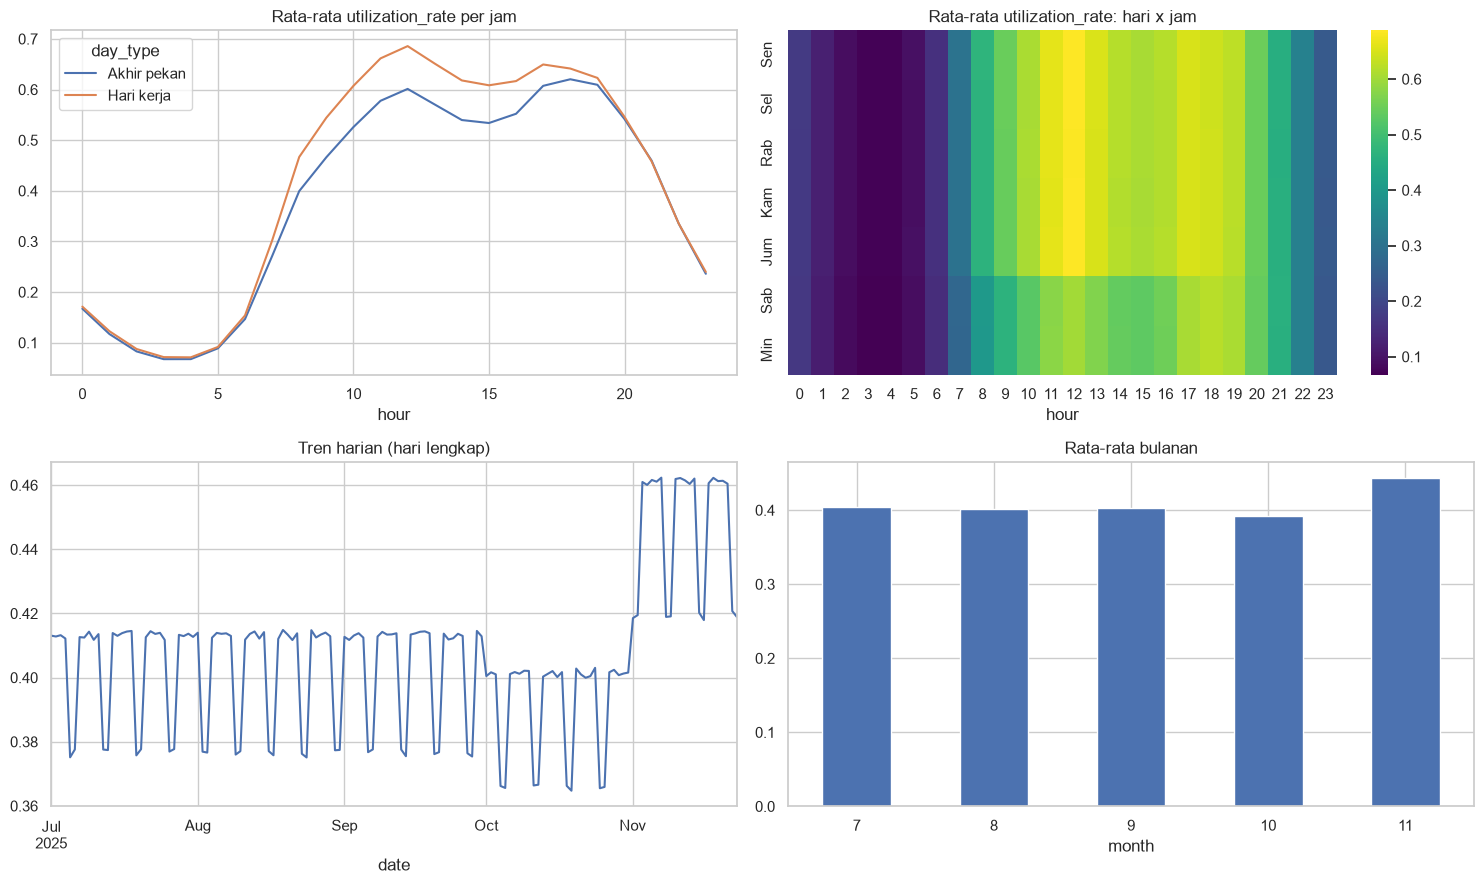

In [14]:
day_names = ["Sen", "Sel", "Rab", "Kam", "Jum", "Sab", "Min"]
n_stations = df_train["station_id"].nunique()
expected_daily_rows = expected_daily_records * n_stations


def add_time_features(df_dataset: pd.DataFrame) -> pd.DataFrame:
    """Turunkan fitur waktu dasar dari timestamp untuk keperluan eksplorasi."""
    return df_dataset.assign(
        hour=df_dataset[timestamp_col].dt.hour,
        day_of_week=df_dataset[timestamp_col].dt.dayofweek,
        month=df_dataset[timestamp_col].dt.month,
        date=df_dataset[timestamp_col].dt.normalize(),
    )


df_target_time = add_time_features(df_train[[timestamp_col, target_col]])
df_target_time["day_type"] = np.where(df_target_time["day_of_week"] >= 5, "Akhir pekan", "Hari kerja")

hourly_by_day_type = df_target_time.groupby(["hour", "day_type"])[target_col].mean().unstack()
heatmap_data = df_target_time.pivot_table(index="day_of_week", columns="hour", values=target_col, aggfunc="mean")
heatmap_data.index = day_names

daily_stats = df_target_time.groupby("date")[target_col].agg(n_rows="size", mean_target="mean")
is_complete_day = daily_stats["n_rows"] == expected_daily_rows
daily_mean_complete = daily_stats.loc[is_complete_day, "mean_target"]
monthly_mean = df_target_time.groupby("month")[target_col].mean()

print(f"Jam dengan rata-rata tertinggi per tipe hari:\n{hourly_by_day_type.idxmax()}")
print(f"Hari tidak lengkap yang dikecualikan dari tren harian: {(~is_complete_day).sum()}")

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
hourly_by_day_type.plot(ax=axes[0, 0], title="Rata-rata utilization_rate per jam")
sns.heatmap(heatmap_data, cmap="viridis", ax=axes[0, 1])
axes[0, 1].set_title("Rata-rata utilization_rate: hari x jam")
daily_mean_complete.plot(ax=axes[1, 0], title="Tren harian (hari lengkap)")
monthly_mean.plot.bar(ax=axes[1, 1], rot=0, title="Rata-rata bulanan")
plt.tight_layout()
plt.show()

#### ****Temuan Distribusi dan Pola Temporal Target****

**Distribusi target**
- Sebanyak 3,29% baris (34.662) berada tepat di 0,02 dan 4,71% (49.603) tepat di 0,98, sehingga sekitar 8% target menumpuk di dua batas. Ini mengonfirmasi target terpotong pada 0,02 dan 0,98.
- Distribusi bimodal dan mendatar: satu puncak di nilai rendah (sekitar 0,05 sampai 0,1), satu puncak lebih landai di sekitar 0,5 sampai 0,6, dan lonjakan di kedua batas. Skewness 0,347 dan kurtosis -1,077 menunjukkan sebaran yang hampir rata dengan kemiringan ringan ke kanan.
- Rata-rata target per stasiun berkisar sekitar 0,22 sampai 0,64 dengan konsentrasi di sekitar 0,33 sampai 0,35. Perbedaan antarstasiun nyata, tetapi lebih sempit daripada perbedaan antarjam (sekitar 0,07 sampai 0,69).

**Pola harian**
- Utilisasi terendah terjadi pukul 03.00 sampai 04.00 (sekitar 0,07) dan naik tajam mulai pukul 06.00.
- Hari kerja memiliki puncak pukul 12.00 (sekitar 0,69) dan puncak kedua pukul 17.00 sampai 18.00 (sekitar 0,65), dengan lekukan turun pukul 15.00.
- Akhir pekan lebih rendah pada siang hari (puncak sekitar 0,60 pukul 12.00 dan sekitar 0,62 pukul 18.00), lalu menyamai hari kerja sesudah pukul 19.00. Heatmap menunjukkan Senin sampai Jumat serupa, sedangkan Sabtu dan Minggu serupa satu sama lain.

**Tren dan perubahan level**
- Terdapat siklus mingguan yang stabil: rata-rata harian akhir pekan lebih rendah sekitar 0,035 sampai 0,04 dibanding hari kerja.
- Level berubah mendadak pada awal bulan, bukan bertahap. Juli sampai September stabil (hari kerja sekitar 0,413), turun pada awal Oktober (sekitar 0,401), lalu naik tajam pada awal November (sekitar 0,461). Rata-rata bulanan (0,404; 0,401; 0,404; 0,392; 0,443) konsisten dengan pola ini.
- Penyebab perubahan level belum diketahui. Test mencakup 24 sampai 30 November dan seluruh Desember, sedangkan Desember tidak ada di train. Penyebabnya diperiksa pada sel berikutnya.
- 24 November hanya berisi 20 timestamp (sampai pukul 09.30) sehingga dikecualikan dari tren harian.

---

### ****PENYEBAB PERUBAHAN LEVEL DAN KARAKTERISTIK STASIUN****

#### Kandidat Penyebab Perubahan Level Bulanan

Membandingkan rata-rata bulanan target dengan harga bensin, suhu, curah hujan, proporsi acara lokal, dan komposisi cuaca, lalu menyandingkan tren harian target, harga bensin, dan suhu. Tujuannya mencari faktor yang bergerak bersamaan dengan lonjakan level pada awal Oktober dan November.

Rata-rata bulanan target dan kandidat pemicu:


,utilization_rate,gas_price_per_gallon,temperature_f,precipitation_mm,proporsi_acara
month,,,,,
7,0.404,3.841,87.391,0.488,0.024
8,0.401,3.841,87.405,0.490,0.024
9,0.404,3.841,87.407,0.483,0.024
10,0.392,3.842,67.403,0.480,0.025
11,0.443,4.149,49.768,0.770,0.024


Proporsi weather_condition per bulan:


weather_condition,clear,cloudy,extreme_heat,freezing,heavy_rain,light_rain,partly_cloudy
month,,,,,,,
7,0.338,0.170,0.225,0.000,0.013,0.084,0.170
8,0.340,0.170,0.225,0.000,0.013,0.083,0.169
9,0.340,0.171,0.225,0.000,0.013,0.082,0.169
10,0.453,0.225,0.000,0.000,0.013,0.082,0.227
11,0.351,0.177,0.000,0.142,0.021,0.132,0.176


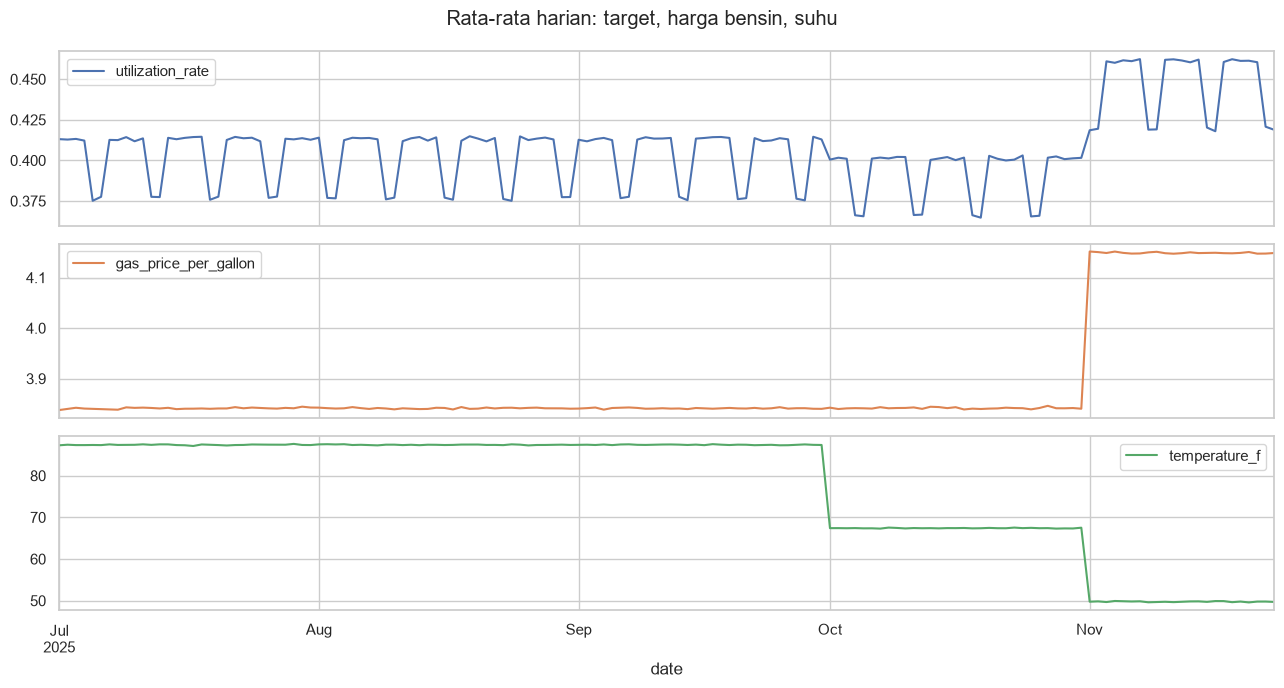

In [15]:
weather_col = "weather_condition"
driver_cols = ["gas_price_per_gallon", "temperature_f", "precipitation_mm"]

df_drivers = df_train[[timestamp_col, target_col, "local_event", weather_col] + driver_cols].assign(
    month=lambda df: df[timestamp_col].dt.month,
    date=lambda df: df[timestamp_col].dt.normalize(),
    is_event=lambda df: (df["local_event"] != "none").astype(int),
)

monthly_drivers = (
    df_drivers.groupby("month")[[target_col] + driver_cols + ["is_event"]]
    .mean()
    .rename(columns={"is_event": "proporsi_acara"})
    .round(3)
)
print("Rata-rata bulanan target dan kandidat pemicu:")
display(monthly_drivers)

print("Proporsi weather_condition per bulan:")
display(pd.crosstab(df_drivers["month"], df_drivers[weather_col], normalize="index").round(3))

complete_days = is_complete_day[is_complete_day].index
daily_drivers = (
    df_drivers.groupby("date")[[target_col, "gas_price_per_gallon", "temperature_f"]]
    .mean()
    .loc[complete_days]
)

daily_drivers.plot(subplots=True, figsize=(13, 7), title="Rata-rata harian: target, harga bensin, suhu")
plt.tight_layout()
plt.show()

#### Target Menurut Karakteristik Stasiun

Membandingkan rata-rata target antarkategori lokasi, charger, harga, jaringan, dan kota, serta pola jam per location_type. Tabel jam terendah dan tertinggi per kota juga memeriksa apakah timestamp seragam dalam waktu lokal di semua kota. Tujuannya menemukan fitur stasiun yang membedakan tingkat dan pola utilisasi.

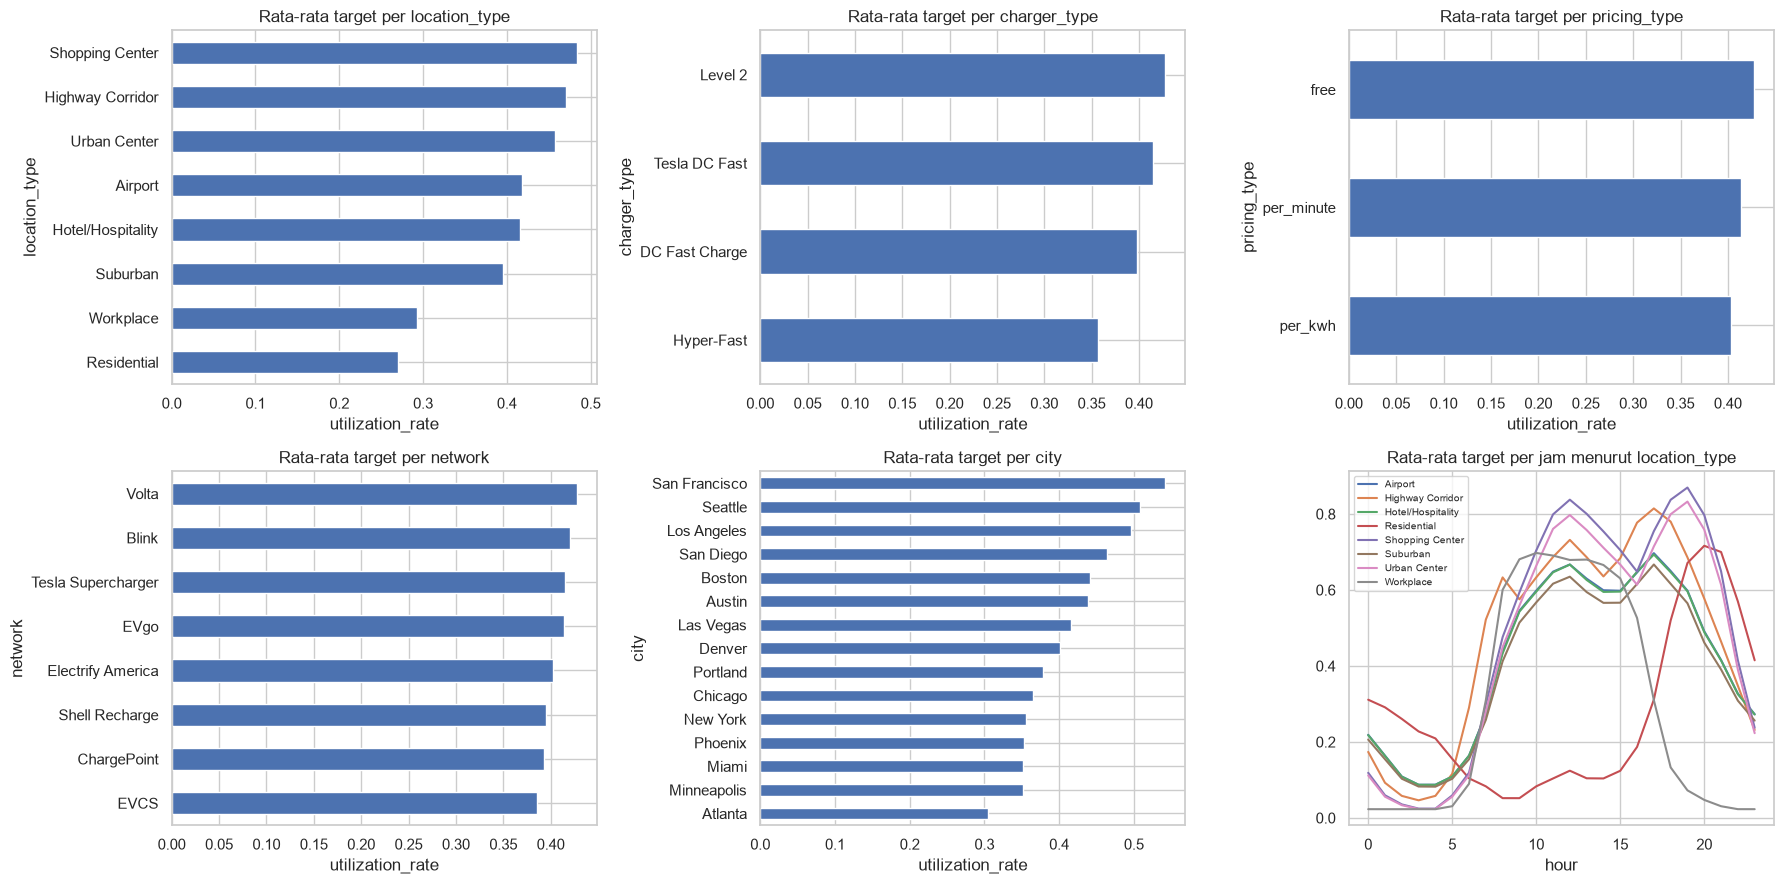

,jam_terendah,jam_tertinggi
city,,
Atlanta,4,12
Austin,3,12
Boston,3,12
Chicago,3,17
Denver,3,12
Las Vegas,3,18
Los Angeles,4,12
Miami,3,17
Minneapolis,4,18


In [16]:
static_cat_cols = ["location_type", "charger_type", "pricing_type", "network", "city"]

df_hour = df_train[[timestamp_col, target_col, "city", "location_type"]].assign(
    hour=lambda df: df[timestamp_col].dt.hour
)

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for ax, col in zip(axes.ravel(), static_cat_cols):
    df_train.groupby(col)[target_col].mean().sort_values().plot.barh(
        ax=ax, title=f"Rata-rata target per {col}"
    )
    ax.set_xlabel(target_col)

hourly_by_location = df_hour.groupby(["hour", "location_type"])[target_col].mean().unstack()
hourly_by_location.plot(ax=axes[1, 2], title="Rata-rata target per jam menurut location_type")
axes[1, 2].legend(fontsize=7)
plt.tight_layout()
plt.show()

hourly_by_city = df_hour.groupby(["city", "hour"])[target_col].mean().unstack()
display(pd.DataFrame({
    "jam_terendah": hourly_by_city.idxmin(axis=1),
    "jam_tertinggi": hourly_by_city.idxmax(axis=1),
}))

#### ****Temuan Kandidat Penyebab Perubahan Level dan Karakteristik Stasiun****

**Perubahan level bulanan**
- Suhu, harga bensin, dan komposisi cuaca berubah berundak pada awal bulan dan hampir datar di dalam bulan, sama seperti target.
  - Juli sampai September: suhu rata-rata sekitar 87,4 F, harga bensin 3,841, dan extreme_heat sekitar 22,5% baris.
  - Oktober: suhu turun ke 67,4 F dan extreme_heat hilang, sedangkan harga bensin tetap 3,842. Target turun dari 0,404 (September) menjadi 0,392.
  - November: suhu turun ke 49,8 F, harga bensin naik ke 4,149 (sekitar +8%), curah hujan naik (0,48 menjadi 0,77), dan muncul freezing (14,2%). Target naik menjadi 0,443.
- Proporsi acara lokal konstan (sekitar 2,4 sampai 2,5% per bulan), sehingga bukan penyebab perubahan level.
- Hanya ada lima rezim bulanan, dan pada November harga bensin, suhu, dan cuaca berubah bersamaan. Pengaruh masing-masing tidak dapat dipisahkan dari deret bulanan saja, sehingga pemisahannya bertumpu pada variasi di dalam bulan.
- Rata-rata keseluruhan test hampir sama dengan November di train: suhu 49,77 F vs 49,77 F, harga bensin 4,149 vs 4,149, freezing 14,30% vs 14,2%. Test tampak melanjutkan rezim November, sehingga 24 hari November di train menjadi acuan terdekat untuk periode test (dipastikan per periode pada sel berikutnya).

**Karakteristik stasiun**
- location_type paling membedakan target: dari sekitar 0,27 (Residential) dan 0,29 (Workplace) sampai sekitar 0,48 (Shopping Center), diikuti Highway Corridor dan Urban Center (sekitar 0,46 sampai 0,47).
- city juga lebar: sekitar 0,30 (Atlanta) sampai 0,54 (San Francisco). Empat kota teratas adalah San Francisco, Seattle, Los Angeles, dan San Diego.
- charger_type (sekitar 0,36 sampai 0,43), pricing_type (sekitar 0,40 sampai 0,43), dan network (sekitar 0,385 sampai 0,43) berbeda tipis. Selisihnya bisa mencerminkan komposisi lokasi atau keterkaitan antarkolom (misalnya Volta hanya Level 2), sehingga perlu dipastikan pada pemodelan.
- Pola jam sangat bergantung pada location_type:
  - Workplace tinggi pukul 08.00 sampai 15.00 (sekitar 0,6 sampai 0,7), turun tajam sesudah pukul 16.00, dan nyaris kosong pada malam hari (sekitar 0,03, mendekati batas bawah 0,02).
  - Residential berlawanan: rendah siang hari (sekitar 0,05 sampai 0,13) dan puncak malam hari sekitar 0,72 pukul 20.00.
  - Shopping Center dan Urban Center memiliki dua puncak tinggi (sekitar 0,84 pukul 12.00 dan 0,87 pukul 19.00), sedangkan Highway Corridor memuncak sekitar 0,82 pukul 17.00.
  - Pola jam pada seluruh data adalah campuran dari pola-pola ini, sehingga interaksi location_type x jam harus dimodelkan.
- Jam terendah tiap kota selalu pukul 03.00 atau 04.00, termasuk kota zona waktu Timur dan Pasifik, sehingga timestamp tampak sudah dalam waktu lokal dan tidak perlu penyesuaian zona waktu. Jam tertinggi bervariasi (pukul 12.00 di 9 kota, 17.00 sampai 19.00 di 6 kota) karena puncak siang dan sore nilainya berdekatan.

---

### ****REZIM LINGKUNGAN, NILAI KOSONG, DAN FAKTOR KONTEKSTUAL****

#### Kesamaan Rezim Lingkungan Train dan Test

Membandingkan rata-rata suhu, curah hujan, harga bensin, dan komposisi cuaca per periode (bulan pada train, akhir November dan Desember pada test), per kota, serta profil suhu per jam. Tujuannya memastikan apakah test melanjutkan rezim November dan apakah ada variasi antarkota dan antarjam yang dapat dimanfaatkan untuk imputasi.

Rata-rata lingkungan per periode:


,temperature_f,precipitation_mm,gas_price_per_gallon
period,,,
test_2025-11,49.804,0.782,4.148
test_2025-12,49.765,0.787,4.149
train_2025-07,87.391,0.488,3.841
train_2025-08,87.405,0.490,3.841
train_2025-09,87.407,0.483,3.841
train_2025-10,67.403,0.480,3.842
train_2025-11,49.768,0.770,4.149


Proporsi weather_condition per periode:


weather_condition,clear,cloudy,extreme_heat,freezing,heavy_rain,light_rain,partly_cloudy
period,,,,,,,
test_2025-11,0.353,0.175,0.000,0.142,0.021,0.134,0.176
test_2025-12,0.350,0.176,0.000,0.143,0.022,0.132,0.177
train_2025-07,0.338,0.170,0.225,0.000,0.013,0.084,0.170
train_2025-08,0.340,0.170,0.225,0.000,0.013,0.083,0.169
train_2025-09,0.340,0.171,0.225,0.000,0.013,0.082,0.169
train_2025-10,0.453,0.225,0.000,0.000,0.013,0.082,0.227
train_2025-11,0.351,0.177,0.000,0.142,0.021,0.132,0.176


Rata-rata temperature_f per kota dan periode:


period,test_2025-11,test_2025-12,train_2025-07,train_2025-08,train_2025-09,train_2025-10,train_2025-11
city,,,,,,,
Atlanta,35.19,35.01,80.00,80.00,79.96,60.05,34.92
Austin,65.17,65.02,95.03,95.06,95.01,75.04,64.96
Boston,35.12,34.89,80.03,80.06,79.98,59.97,35.05
Chicago,34.98,34.97,79.96,79.96,79.99,60.05,35.07
Denver,34.75,34.94,79.95,80.02,80.07,60.03,34.98
Las Vegas,65.13,65.01,95.00,94.99,94.97,75.03,65.00
Los Angeles,64.97,64.92,95.06,94.94,95.03,74.94,64.87
Miami,65.01,65.05,94.96,94.93,94.97,75.02,64.98
Minneapolis,35.11,35.00,79.96,79.99,80.06,59.97,35.00


Rata-rata gas_price_per_gallon per kota dan periode:


period,test_2025-11,test_2025-12,train_2025-07,train_2025-08,train_2025-09,train_2025-10,train_2025-11
city,,,,,,,
Atlanta,3.73,3.72,3.45,3.45,3.45,3.45,3.73
Austin,3.72,3.73,3.45,3.45,3.45,3.45,3.73
Boston,3.73,3.73,3.45,3.45,3.45,3.45,3.73
Chicago,3.73,3.73,3.45,3.45,3.45,3.45,3.73
Denver,3.72,3.73,3.45,3.45,3.45,3.45,3.73
Las Vegas,3.73,3.72,3.45,3.45,3.45,3.45,3.73
Los Angeles,5.24,5.24,4.85,4.85,4.85,4.85,5.24
Miami,3.72,3.73,3.45,3.45,3.45,3.45,3.72
Minneapolis,3.73,3.73,3.45,3.45,3.45,3.45,3.73


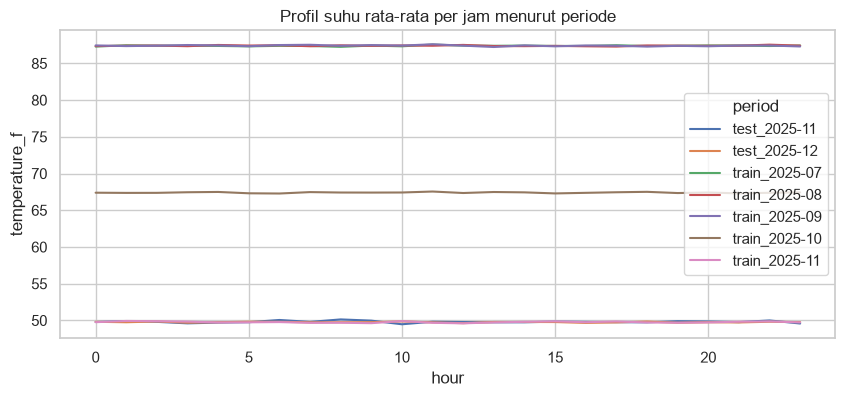

In [17]:
env_numeric_cols = ["temperature_f", "precipitation_mm", "gas_price_per_gallon"]

df_env = pd.concat(
    [
        df_dataset[[timestamp_col, "city", weather_col] + env_numeric_cols].assign(dataset=dataset_name.lower())
        for dataset_name, df_dataset in datasets.items()
    ],
    ignore_index=True,
)
df_env["period"] = df_env["dataset"] + "_" + df_env[timestamp_col].dt.strftime("%Y-%m")
df_env["hour"] = df_env[timestamp_col].dt.hour

print("Rata-rata lingkungan per periode:")
display(df_env.groupby("period")[env_numeric_cols].mean().round(3))

print("Proporsi weather_condition per periode:")
display(pd.crosstab(df_env["period"], df_env[weather_col], normalize="index").round(3))

for env_col in ["temperature_f", "gas_price_per_gallon"]:
    print(f"Rata-rata {env_col} per kota dan periode:")
    display(df_env.pivot_table(index="city", columns="period", values=env_col, aggfunc="mean").round(2))

df_env.pivot_table(index="hour", columns="period", values="temperature_f", aggfunc="mean").plot(
    figsize=(10, 4), title="Profil suhu rata-rata per jam menurut periode"
)
plt.ylabel("temperature_f")
plt.show()

#### Pola Nilai Kosong

Menganalisis apakah nilai kosong temperature_f dan precipitation_mm acak atau terkonsentrasi (per bulan, jam, kota, dan stasiun), panjang blok kosong berurutan per stasiun, dan hubungannya dengan target. Tujuannya menentukan strategi imputasi berbasis waktu yang tepat.

In [18]:
missing_cols = ["temperature_f", "precipitation_mm"]
flag_cols = [f"missing_{col}" for col in missing_cols]


def get_missing_run_lengths(df_dataset: pd.DataFrame, col: str) -> pd.Series:
    """Hitung panjang blok nilai kosong berurutan pada setiap stasiun (terurut waktu)."""
    df_sorted = df_dataset.sort_values(["station_id", timestamp_col])
    is_missing = df_sorted[col].isna()
    is_new_block = (is_missing != is_missing.shift()) | (df_sorted["station_id"] != df_sorted["station_id"].shift())
    runs = is_missing.groupby(is_new_block.cumsum()).agg(is_missing="first", length="size")
    return runs.loc[runs["is_missing"], "length"]


df_flags = df_train[[timestamp_col, "city", "station_id", target_col]].copy()
df_flags["month"] = df_flags[timestamp_col].dt.month
df_flags["hour"] = df_flags[timestamp_col].dt.hour
for col, flag_col in zip(missing_cols, flag_cols):
    df_flags[flag_col] = df_train[col].isna()

for group_col in ["month", "hour", "city"]:
    print(f"Persentase nilai kosong per {group_col} (train):")
    display((df_flags.groupby(group_col)[flag_cols].mean() * 100).round(2).T)

print("Sebaran persentase nilai kosong antarstasiun (train):")
display((df_flags.groupby("station_id")[flag_cols].mean() * 100).describe().round(2))

print("Kekosongan bersamaan (baris: suhu kosong, kolom: hujan kosong):")
display(pd.crosstab(df_flags[flag_cols[0]], df_flags[flag_cols[1]]))

for dataset_name, df_dataset in datasets.items():
    for col in missing_cols:
        run_lengths = get_missing_run_lengths(df_dataset, col)
        print(f"{dataset_name} | {col}: {len(run_lengths):,} blok kosong berurutan")
        display(run_lengths.describe(percentiles=[0.5, 0.9, 0.99]).round(2).to_frame(col).T)

for col, flag_col in zip(missing_cols, flag_cols):
    print(f"Rata-rata target menurut status kosong {col}:")
    display(df_flags.groupby(flag_col)[target_col].agg(["mean", "count"]).round(3))

Persentase nilai kosong per month (train):


month,7,8,9,10,11
missing_temperature_f,4.12,4.25,4.15,4.22,4.22
missing_precipitation_mm,2.29,2.29,2.30,2.24,2.28


Persentase nilai kosong per hour (train):


hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
missing_temperature_f,4.05,4.16,4.29,4.26,4.27,4.34,4.24,4.28,4.15,4.11,...,4.16,4.12,4.00,4.32,4.18,4.30,4.17,4.16,4.24,4.18
missing_precipitation_mm,2.20,2.26,2.29,2.29,2.24,2.17,2.27,2.26,2.30,2.36,...,2.29,2.29,2.31,2.28,2.41,2.24,2.40,2.33,2.34,2.20


Persentase nilai kosong per city (train):


...

,count,mean,std,min,50%,90%,99%,max
precipitation_mm,6021.0,1.03,0.16,1.0,1.0,1.0,2.0,3.0


Rata-rata target menurut status kosong temperature_f:


,mean,count
missing_temperature_f,,
False,0.407,1010040
True,0.404,44160


Rata-rata target menurut status kosong precipitation_mm:


,mean,count
missing_precipitation_mm,,
False,0.407,1030168
True,0.409,24032


#### Pengaruh Acara Lokal, Cuaca, dan Hujan terhadap Target

Menghitung uplift target, yaitu selisih target dengan rata-rata stasiun yang sama pada bulan, jam, dan tipe hari (hari kerja atau akhir pekan) yang sama, menurut jenis acara, kondisi cuaca, dan kelas curah hujan, serta jam kejadian tiap jenis acara. Tujuannya menilai pengaruh faktor ini di dalam bulan yang sama sehingga terpisah dari perubahan level bulanan.

In [19]:
event_col = "local_event"
baseline_keys = ["station_id", "month", "is_weekend", "hour"]

df_uplift = df_train[[timestamp_col, "station_id", target_col, event_col, weather_col, "precipitation_mm"]].assign(
    month=lambda df: df[timestamp_col].dt.month,
    hour=lambda df: df[timestamp_col].dt.hour,
    is_weekend=lambda df: df[timestamp_col].dt.dayofweek >= 5,
)
df_uplift["baseline_target"] = df_uplift.groupby(baseline_keys)[target_col].transform("mean")
df_uplift["uplift"] = df_uplift[target_col] - df_uplift["baseline_target"]
df_uplift["precip_class"] = pd.cut(
    df_uplift["precipitation_mm"],
    bins=[-np.inf, 0, 2, 10, np.inf],
    labels=["0 mm", "0-2 mm", "2-10 mm", ">10 mm"],
)

for group_col in [event_col, weather_col, "precip_class"]:
    print(f"Uplift target menurut {group_col}:")
    display(df_uplift.groupby(group_col, observed=True)["uplift"].agg(["mean", "std", "count"]).round(3))

print("Jam kejadian per jenis acara:")
display(
    df_uplift.loc[df_uplift[event_col] != "none"]
    .groupby(event_col)["hour"]
    .describe()[["min", "25%", "50%", "75%", "max"]]
)

Uplift target menurut local_event:


,mean,std,count
local_event,,,
concert,-0.000,0.067,6373
conference,-0.001,0.067,6410
festival,-0.000,0.067,6420
none,0.000,0.067,1028711
sports_game,-0.001,0.068,6286


Uplift target menurut weather_condition:


,mean,std,count
weather_condition,,,
clear,-0.004,0.064,385053
cloudy,-0.004,0.064,192886
extreme_heat,0.028,0.069,149136
freezing,0.036,0.071,23953
heavy_rain,-0.061,0.074,15051
light_rain,-0.007,0.066,95661
partly_cloudy,-0.004,0.064,192460


Uplift target menurut precip_class:


,mean,std,count
precip_class,,,
0 mm,0.002,0.067,922006
0-2 mm,-0.006,0.065,35903
2-10 mm,-0.007,0.066,57579
>10 mm,-0.061,0.074,14680


Jam kejadian per jenis acara:


,min,25%,50%,75%,max
local_event,,,,,
concert,0.0,6.0,12.0,18.0,23.0
conference,0.0,5.0,11.0,17.0,23.0
festival,0.0,5.0,11.0,17.0,23.0
sports_game,0.0,6.0,12.0,17.0,23.0


#### ****Temuan Kesamaan Rezim, Pola Nilai Kosong, dan Uplift Faktor Kontekstual****

**Kesamaan rezim train dan test**
- test_2025-11 dan test_2025-12 hampir identik dengan train_2025-11 pada suhu (49,8 vs 49,77), curah hujan (0,78 vs 0,77), harga bensin (4,148 vs 4,149), dan proporsi cuaca (freezing 14,2 sampai 14,3%, tanpa extreme_heat). Kesamaan ini konsisten sampai level kota: suhu dan harga bensin per kota pada test_2025-11 dan test_2025-12 sama persis dengan train_2025-11 (selisih di bawah 0,2). Profil suhu per jam pada grafik juga saling menumpuk sempurna antarperiode yang serupa.
- Perubahan level target bertahap dua kali: turun di Oktober (suhu turun ke 67,4 F, extreme_heat hilang, harga bensin belum berubah) dan naik tajam di November (suhu turun lagi ke 49,8 F, freezing muncul, dan harga bensin baru naik sekitar 8%). Karena harga bensin hanya berubah bersamaan lonjakan November, sedangkan suhu dan cuaca berubah pada kedua titik, suhu dan kondisi cuaca tampak sebagai pendorong utama, dan harga bensin kemungkinan tumpang tindih (confounded) dengan keduanya.
- 39 hari test seluruhnya berada dalam rezim yang sama dengan 24 hari November di train, sehingga November adalah acuan tervalidasi untuk memeriksa performa model pada rezim mendekati test.

**Pola nilai kosong**
- Persentase kosong temperature_f (sekitar 4,0 sampai 4,3%) dan precipitation_mm (sekitar 2,2 sampai 2,4%) stabil di semua bulan, jam, kota, dan stasiun (std antarstasiun kecil: 0,23 dan 0,16). Kekosongan kedua kolom nyaris independen (1.020 kosong bersamaan, dekat dengan 1.006 yang diharapkan bila acak). Pola ini konsisten dengan hilang acak sepenuhnya (MCAR), bukan terkonsentrasi pada waktu atau stasiun tertentu.
- Blok kosong berurutan sangat pendek: median 1 baris, maksimum hanya 4 (setara 2 jam) pada train maupun test. Setiap titik kosong selalu memiliki tetangga waktu yang terisi.
- Rata-rata target hampir sama antara baris yang kosong dan yang terisi (0,404 vs 0,407 untuk suhu, 0,409 vs 0,407 untuk hujan), sehingga status kosong tidak informatif terhadap target dan aman diabaikan sebagai fitur.
- Implikasi: karena hilang bersifat acak dan blok sangat pendek, imputasi berbasis kelompok waktu (rata-rata per stasiun x jam, atau kota x bulan x jam) sudah memadai. Ini tetap sejalan dengan arahan panitia, karena yang dihindari adalah rata-rata global tunggal, bukan rata-rata bersyarat.

**Uplift acara lokal, cuaca, dan hujan**
- local_event nyaris tidak berpengaruh: uplift rata-rata semua jenis acara mendekati 0 (-0,001 sampai -0,000) dengan simpangan sebesar variasi acak (std sekitar 0,067) dan jumlah kejadian kecil (sekitar 6.300 sampai 6.400 baris per jenis). Empat jenis acara juga tersebar sepanjang hari (jam minimum 0, maksimum 23) tanpa waktu khas. Faktor ini kemungkinan tidak bernilai prediktif meski disebut di latar belakang soal.
- weather_condition berpengaruh meski sudah dikendalikan terhadap stasiun, bulan, jam, dan tipe hari: extreme_heat (+0,028) dan freezing (+0,036) menaikkan target, sedangkan heavy_rain menurunkannya tajam (-0,061). clear, cloudy, dan partly_cloudy mendekati netral (sekitar -0,004).
- precipitation_mm sejalan dengan itu: uplift mendekati 0 sampai curah hujan di atas 10 mm, yang turun -0,061, sama besarnya dengan heavy_rain. Ini memperkuat precipitation_mm dan weather_condition sebagai sinyal yang konsisten, bukan sekadar noise.

---

### ****OUTLIER CUACA DAN KORELASI FITUR NUMERIK****

#### Analisis Outlier Cuaca

Menandai nilai temperature_f dan precipitation_mm yang menyimpang jauh (lebih dari 4 standar deviasi) dari rata-rata kota dan bulan yang sama, serta menyilangkan precipitation_mm dan temperature_f dengan weather_condition. Tujuannya membedakan pencilan akibat kesalahan sensor dari kejadian cuaca ekstrem nyata yang konsisten dengan label cuaca.

In [20]:
def flag_group_outliers(df_dataset: pd.DataFrame, value_col: str, group_cols: list, z_thresh: float = 4) -> pd.Series:
    """Tandai nilai dengan z-score lebih dari z_thresh terhadap rata-rata kelompoknya."""
    grouped = df_dataset.groupby(group_cols)[value_col]
    group_mean = grouped.transform("mean")
    group_std = grouped.transform("std").replace(0, np.nan)
    return ((df_dataset[value_col] - group_mean) / group_std).abs() > z_thresh


df_train_month = df_train.assign(month=df_train[timestamp_col].dt.month)

for col in ["temperature_f", "precipitation_mm"]:
    df_valid = df_train_month.dropna(subset=[col])
    is_outlier = flag_group_outliers(df_valid, col, ["city", "month"])
    print(f"Outlier {col} (>4 std dari rata-rata kota-bulan): {is_outlier.sum():,} baris ({is_outlier.mean()*100:.2f}%)")

print("Statistik temperature_f per weather_condition:")
display(df_train.groupby(weather_col)["temperature_f"].describe()[["mean", "std", "min", "max"]].round(2))

precip_bins = [-np.inf, 0, 2, 10, np.inf]
precip_labels = ["0 mm", "0-2 mm", "2-10 mm", ">10 mm"]
df_train_month["precip_class"] = pd.cut(df_train_month["precipitation_mm"], bins=precip_bins, labels=precip_labels)

print("precip_class x weather_condition (jumlah baris):")
display(pd.crosstab(df_train_month["precip_class"], df_train_month[weather_col]))

Outlier temperature_f (>4 std dari rata-rata kota-bulan): 0 baris (0.00%)
Outlier precipitation_mm (>4 std dari rata-rata kota-bulan): 15,910 baris (1.54%)
Statistik temperature_f per weather_condition:


,mean,std,min,max
weather_condition,,,,
clear,74.77,14.20,32.0,95.0
cloudy,74.76,14.21,32.0,95.0
extreme_heat,100.45,3.49,95.1,110.0
freezing,27.87,2.80,20.1,31.9
heavy_rain,72.88,20.29,20.3,109.5
light_rain,73.02,20.32,20.1,109.8
partly_cloudy,74.75,14.24,32.0,95.0


precip_class x weather_condition (jumlah baris):


weather_condition,clear,cloudy,extreme_heat,freezing,heavy_rain,light_rain,partly_cloudy
precip_class,,,,,,,
0 mm,376218,188452,145737,23392,0,0,188207
0-2 mm,0,0,0,0,0,35903,0
2-10 mm,0,0,0,0,0,57579,0
>10 mm,0,0,0,0,14680,0,0


#### Korelasi Fitur Numerik dan Target

Menghitung korelasi Pearson antara target dan fitur numerik, termasuk fitur waktu (jam, hari dalam minggu, bulan). Tujuannya melihat kekuatan hubungan linear, dengan catatan bahwa hubungan jam terhadap target sudah diketahui bimodal (nonlinear) dari analisis sebelumnya sehingga korelasi Pearson untuk jam kemungkinan tampak lemah walau polanya nyata.

,utilization_rate
utilization_rate,1.000
hour,0.472
gas_price_per_gallon,0.166
ports_total,0.086
month,0.027
temperature_f,0.007
power_output_kw,-0.002
precipitation_mm,-0.015
day_of_week,-0.040


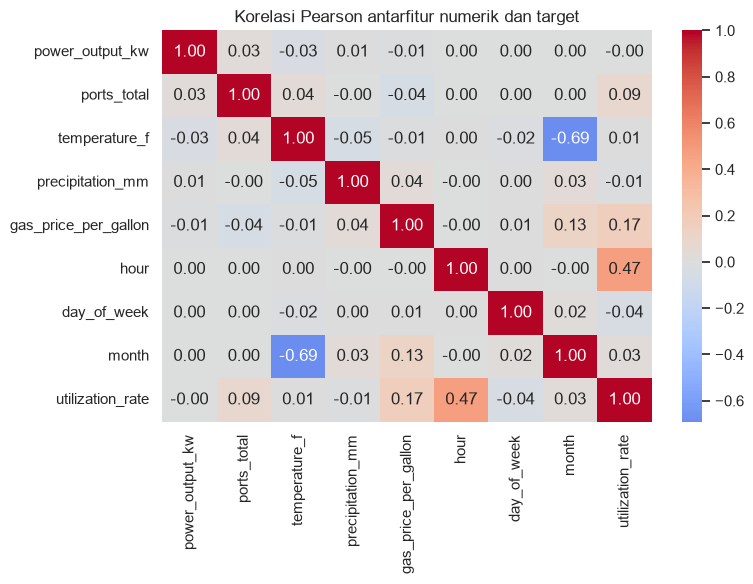

In [21]:
df_corr_features = df_train.assign(
    hour=df_train[timestamp_col].dt.hour,
    day_of_week=df_train[timestamp_col].dt.dayofweek,
    month=df_train[timestamp_col].dt.month,
)
numeric_corr_cols = ["power_output_kw", "ports_total", "temperature_f", "precipitation_mm",
                    "gas_price_per_gallon", "hour", "day_of_week", "month", target_col]

corr_matrix = df_corr_features[numeric_corr_cols].corr().round(3)
display(corr_matrix[[target_col]].sort_values(target_col, ascending=False))

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Korelasi Pearson antarfitur numerik dan target")
plt.tight_layout()
plt.show()

#### ****Temuan Outlier Cuaca dan Korelasi Fitur Numerik****

**Outlier cuaca**
- temperature_f: tidak ada outlier lebih dari 4 std dari rata-rata kota-bulan (0 baris). Sebaran suhu antarkota dan antarbulan sudah homogen.
- precipitation_mm: 15.910 baris (1,54%) melewati ambang 4 std, tetapi ini adalah konsekuensi distribusi yang sangat condong (75% nilainya 0), bukan indikasi noise. Tabel silang precip_class x weather_condition menunjukkan pemetaan yang sepenuhnya konsisten: 0 mm hanya muncul pada clear, cloudy, extreme_heat, freezing, dan partly_cloudy; 0-2 mm dan 2-10 mm hanya pada light_rain; di atas 10 mm hanya pada heavy_rain. Tidak ada satu baris pun yang bertentangan dengan label cuacanya.
- temperature_f menurut weather_condition juga konsisten: extreme_heat selalu 95,1 sampai 110 F (rata-rata 100,45), freezing selalu 20,1 sampai 31,9 F (rata-rata 27,87), sedangkan clear, cloudy, dan partly_cloudy berbagi rentang dan rata-rata yang sama (32 sampai 95 F, sekitar 74,8, std 14,2). heavy_rain dan light_rain punya rentang terluas (20,1 sampai 109,8) karena hujan dapat terjadi pada suhu berapa pun.
- Kesimpulan: nilai precipitation_mm dan temperature_f yang tampak ekstrem adalah kejadian nyata yang konsisten dengan weather_condition, bukan kesalahan sensor. Tidak ditemukan bukti noise pada kedua kolom ini, sehingga tidak perlu penghapusan atau capping outlier pada Data Preparation.

**Korelasi fitur numerik**
- hour berkorelasi paling kuat dengan target (0,472), tetapi ini kemungkinan meremehkan hubungan sebenarnya karena Pearson mengasumsikan linear, sedangkan pola jam sudah diketahui bimodal (lihat temuan pola temporal).
- month hanya berkorelasi 0,027 dengan target meski rata-rata bulanan jelas berbeda, karena perubahannya berundak (bukan naik atau turun monoton) dan tertutup oleh variasi harian dalam bulan yang sama.
- month dan temperature_f berkorelasi -0,69 (multikolinearitas kuat), sejalan dengan temuan rezim bulanan yang bergerak bersamaan.
- gas_price_per_gallon berkorelasi 0,166, konsisten dengan lonjakan bersamaan di November, tetapi kemungkinan tumpang tindih dengan efek suhu dan cuaca, bukan pengaruh independen.
- temperature_f mentah hanya berkorelasi 0,007 dan precipitation_mm mentah -0,015 dengan target, jauh lebih lemah daripada efek kategorikalnya (extreme_heat +0,028, freezing +0,036, hujan lebat -0,061 dari analisis uplift). Ini menunjukkan hubungannya bersifat ambang batas atau kategorikal, bukan linear terhadap nilai mentahnya.
- ports_total (0,086) dan day_of_week (-0,040) berkorelasi lemah tapi sejalan dengan temuan sebelumnya (efek akhir pekan kecil namun nyata). power_output_kw hampir tidak berkorelasi (-0,002).

---

### ****RINGKASAN DATA UNDERSTANDING****

**Struktur data**
- Train: 1.054.200 baris, 21 kolom, 1 Juli sampai 24 November 2025, panel seimbang 150 stasiun x 7.028 timestamp interval 30 menit, tanpa celah maupun duplikat.
- Test: 263.550 baris, 20 kolom (tanpa target), 24 November sampai 31 Desember 2025, 150 stasiun yang sama, tanpa celah maupun duplikat. Data berakhir tepat di 31 Desember 00:00, sehingga celah yang disebut panitia adalah data yang berhenti di titik itu, bukan lubang di tengah rangkaian.
- station_id adalah kunci entitas yang aman. Dua nama dipakai oleh dua stasiun berbeda (Phoenix #11, San Diego #10) dan wajib diperlakukan terpisah. Semua atribut statis lain konsisten per station_id.

**Nilai kosong**
- Hanya pada temperature_f (sekitar 4,2%) dan precipitation_mm (sekitar 2,3%), bersifat acak (MCAR): rata pada semua bulan, jam, kota, dan stasiun, blok kosong berurutan sangat pendek (median 1, maksimum 4 baris), dan tidak berkaitan dengan nilai target. Imputasi berbasis kelompok waktu (misalnya rata-rata stasiun x jam) sudah memadai.

**Target (utilization_rate)**
- Terpotong pada 0,02 dan 0,98 (sekitar 8% baris di kedua batas), bimodal, dan sangat dipengaruhi interaksi jam x location_type: Workplace tinggi siang hari, Residential tinggi malam hari, Shopping Center dan Urban Center dua puncak (siang dan sore).
- Level rata-rata berubah berundak pada awal bulan mengikuti rezim suhu, cuaca, dan (khusus November) harga bensin, bukan tren bertahap. Seluruh periode test berada pada rezim yang identik dengan November di train, sampai level kota, sehingga November adalah acuan tervalidasi terdekat untuk simulasi performa pada rezim mendekati test.
- weather_condition dan precipitation_mm berpengaruh secara kategorikal atau berambang (extreme_heat dan freezing menaikkan, hujan lebat menurunkan tajam), dan nilainya konsisten satu sama lain sehingga bukan noise. local_event nyaris tidak berpengaruh.
- Korelasi Pearson linear lemah untuk sebagian besar fitur karena hubungan yang sebenarnya bersifat nonlinear (jam) atau kategorikal (cuaca), bukan berarti fitur tersebut tidak berguna.

**Implikasi untuk Data Preparation**
1. Validasi model wajib berbasis waktu (bukan random split), idealnya menyisihkan November sebagai validasi karena rezimnya paling mendekati test.
2. Fitur lag atau rolling dari target tidak dapat dipakai pada test karena test tidak memiliki target aktual pada masa lalunya sendiri di luar train.
3. Rekayasa fitur temporal: jam dan hari dalam minggu sebaiknya di-encode siklikal atau kategorikal, bukan linear; interaksi jam x location_type penting.
4. Imputasi temperature_f dan precipitation_mm berbasis kelompok waktu, bukan rata-rata global.
5. Prediksi akhir di-clip ke 0,02 dan 0,98 (bukan 0 dan 1) sesuai rentang data train.
6. station_id dipakai sebagai kunci entitas untuk semua merge, groupby, dan fitur berbasis stasiun.
7. Tidak diperlukan penanganan outlier cuaca, karena nilai ekstrem terbukti kejadian nyata, bukan noise.
8. local_event dapat dipertimbangkan untuk dikeluarkan atau diberi bobot rendah karena sinyalnya sangat lemah.

<div align="center">
  <img src="https://i.pinimg.com/736x/6c/ce/d4/6cced4e1f1e5ea3e441b971eaa80a0d4.jpg" alt="Mao Mao" width="300">
  <h5>Lanjut ke "Data Preparation!"</h5>
</div>